In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import Holt
from sklearn.metrics import mean_squared_error
import numpy as np

In [4]:
try:
    df_tests = pd.read_csv("tests.csv")
    df_sessions = pd.read_csv("sessions.csv")
    df_agents = pd.read_csv("agents.csv")

    print("--- tests.csv ---")
    print(df_tests.info())
    print(df_tests.head())
    print("\n--- sessions.csv ---")
    print(df_sessions.info())
    print(df_sessions.head())
    print("\n--- agents.csv ---")
    print(df_agents.info())
    print(df_agents.head())

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"An error occurred: {e}")
    

--- tests.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151322 entries, 0 to 151321
Data columns (total 21 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          151322 non-null  int64  
 1   session_id  151322 non-null  int64  
 2   avg_down    151322 non-null  float64
 3   avg_jitter  151322 non-null  float64
 4   avg_up      151322 non-null  float64
 5   avg_rtt     151322 non-null  float64
 6   max_down    151322 non-null  float64
 7   max_jitter  151322 non-null  float64
 8   max_up      151322 non-null  float64
 9   max_rtt     151322 non-null  float64
 10  min_down    151322 non-null  float64
 11  min_jitter  151322 non-null  float64
 12  min_rtt     151322 non-null  float64
 13  min_up      151322 non-null  float64
 14  r_packets   151322 non-null  int64  
 15  st_down     151322 non-null  float64
 16  st_up       151322 non-null  float64
 17  st_rtt      151322 non-null  float64
 18  t_packets   151322 non-nul

No Missing Data: All columns have 151,322 non-null entries, so we don't need to impute or drop rows due to NaNs.

Data Types: The key metrics (avg_rtt, avg_down, etc.) are all numeric (float64 or int64), which is good. The created_at and updated_at columns are object (string) type and will need to be converted to datetime objects for time-series analysis.

Potential Bad Data: The head() output shows a row (id 638530) where all metrics are zero, and r_packets (received packets) is 0. These rows likely represent failed or incomplete tests and could skew our analysis.

**Data Merging**

In [5]:
# --- Step 2: Data Cleaning ---

# 1. Convert 'created_at' to datetime objects
# We'll use the 'id' column to check the shape before and after.
print(f"Original df_tests shape: {df_tests.shape}")
df_tests['created_at'] = pd.to_datetime(df_tests['created_at'])

# 2. Filter out rows with 0 received packets
df_tests_cleaned = df_tests[df_tests['r_packets'] > 0].copy()
print(f"Cleaned df_tests shape (r_packets > 0): {df_tests_cleaned.shape}")

# --- Step 3: Data Merging ---

# Merge the cleaned tests with session info
# df_tests_cleaned.session_id -> df_sessions.id
df_merged = pd.merge(
    df_tests_cleaned,
    df_sessions,
    left_on='session_id',
    right_on='id',
    suffixes=('_test', '_session') # Add suffixes to avoid column name conflicts
)

print(f"Merged DataFrame shape: {df_merged.shape}")

# Inspect the new merged DataFrame
print("\n--- Merged DataFrame Info ---")
print(df_merged.info())
print("\n--- Merged DataFrame Head ---")
print(df_merged.head())

Original df_tests shape: (151322, 21)
Cleaned df_tests shape (r_packets > 0): (147346, 21)
Merged DataFrame shape: (147346, 38)

--- Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147346 entries, 0 to 147345
Data columns (total 38 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id_test             147346 non-null  int64         
 1   session_id          147346 non-null  int64         
 2   avg_down            147346 non-null  float64       
 3   avg_jitter          147346 non-null  float64       
 4   avg_up              147346 non-null  float64       
 5   avg_rtt             147346 non-null  float64       
 6   max_down            147346 non-null  float64       
 7   max_jitter          147346 non-null  float64       
 8   max_up              147346 non-null  float64       
 9   max_rtt             147346 non-null  float64       
 10  min_down            147346 non-null  floa

filtered out 3,976 "failed" tests (where r_packets was 0), leaving us with 147,346 valid test records.

merged this with the sessions data. Our new df_merged DataFrame now has 38 columns, linking each test record with its corresponding session profile (p_name), server name (s_name), and client name (c_name). The created_at_test column is also now in the correct datetime format, which is essential for our time-series analysis later.

**Exploratory Data Analysis (EDA) & Visuals**


--- Summary Statistics (for cleaned data) ---
             avg_rtt     avg_jitter       avg_down         avg_up
count  147346.000000  147346.000000  147346.000000  147346.000000
mean      251.351552       5.542893     144.962095     106.400587
std       128.763604       8.409669      78.166015      73.499495
min         0.668867       0.001000       0.095600       0.000000
25%       193.817250       1.629810      82.054350      53.634450
50%       245.506000       3.297600     145.741000      89.295000
75%       264.547000       4.913775     192.867000     148.613750
max       970.055000     310.108000    1690.560000     774.137000

Generating histograms...


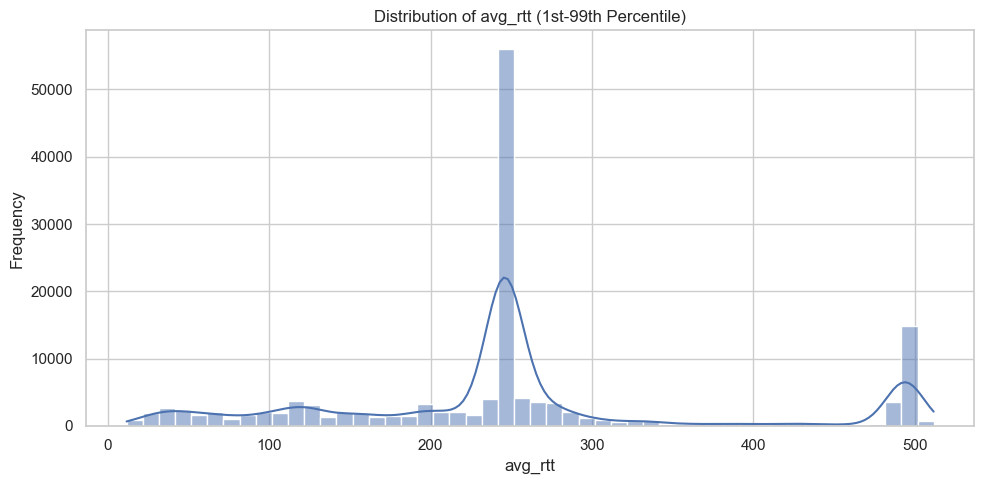

<Figure size 640x480 with 0 Axes>

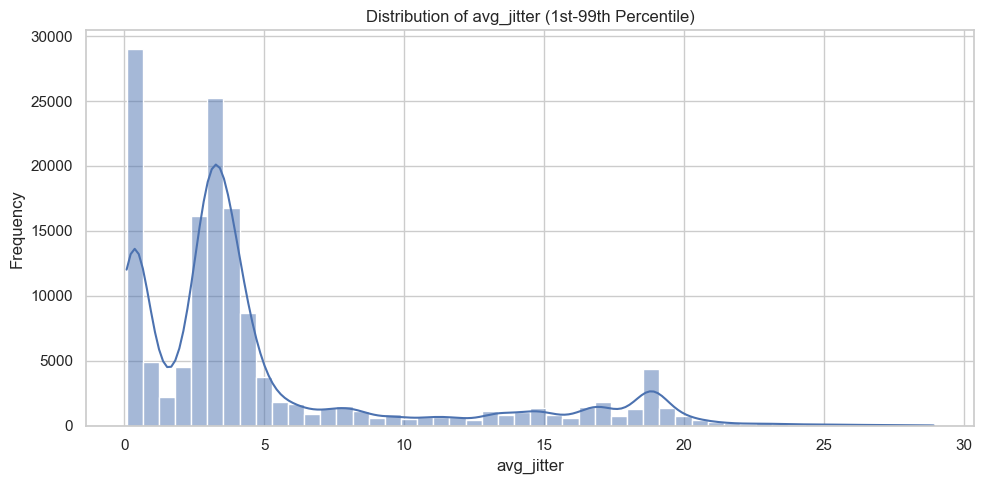

<Figure size 640x480 with 0 Axes>

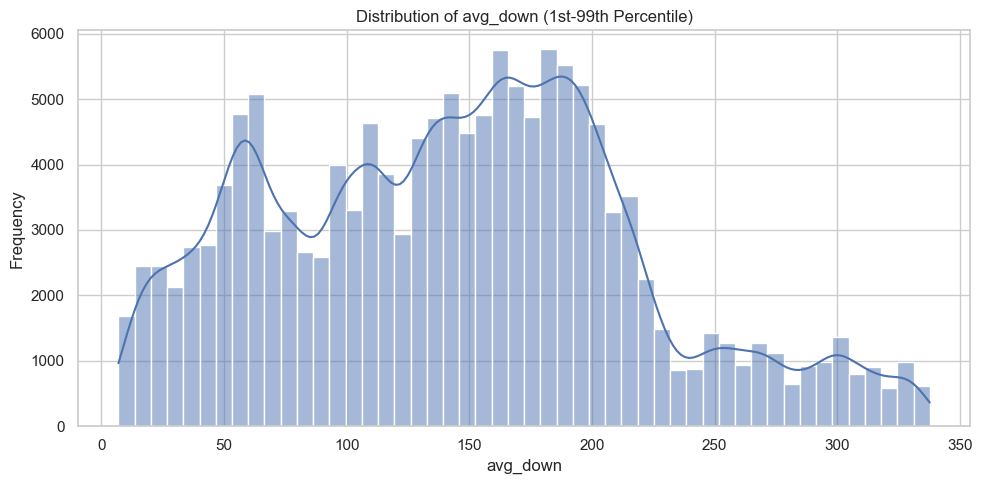

<Figure size 640x480 with 0 Axes>

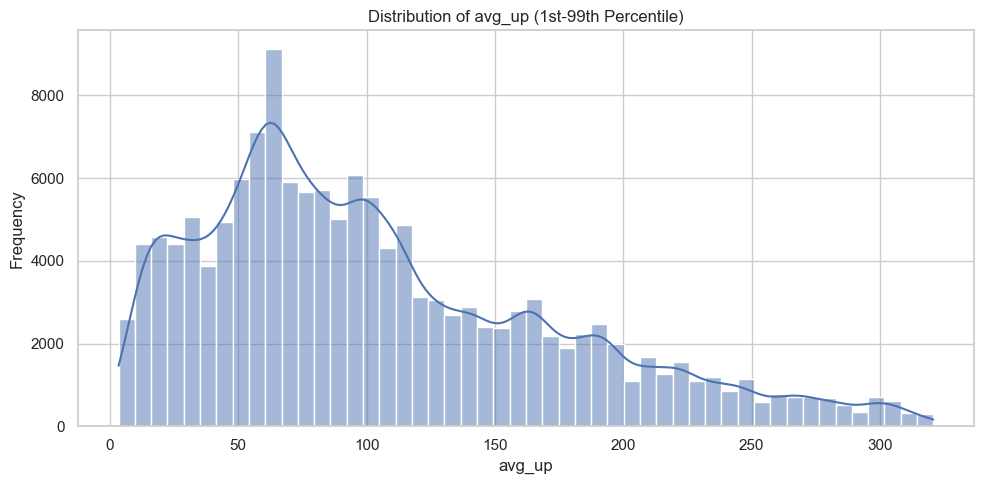

Histograms saved.
Generating correlation heatmap...


<Figure size 640x480 with 0 Axes>

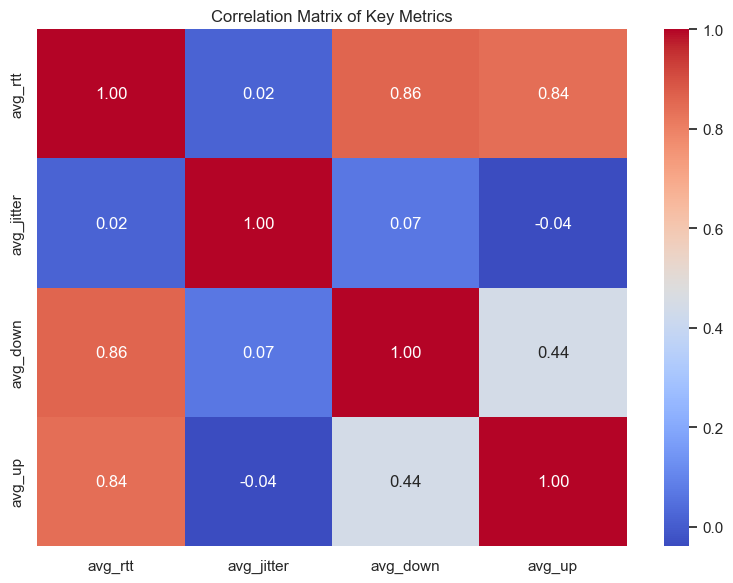

Correlation heatmap saved.
Generating RTT by Profile box plot...


<Figure size 640x480 with 0 Axes>

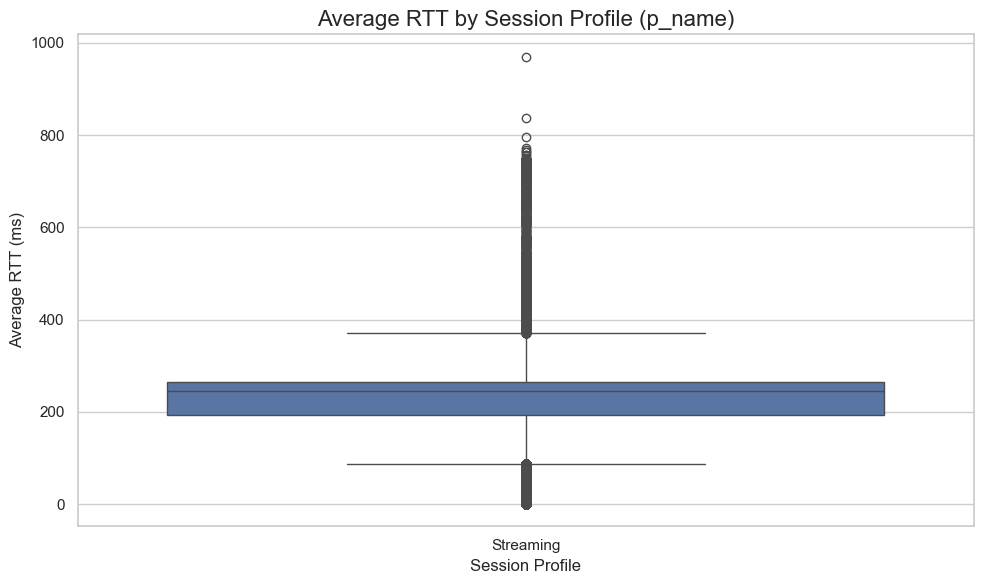

Box plot saved.


<Figure size 640x480 with 0 Axes>

In [9]:
# --- Step 4: EDA & Visuals ---

# Set up plot style
sns.set(style="whitegrid")

# Print summary statistics for key metrics
print("\n--- Summary Statistics (for cleaned data) ---")
print(df_merged[['avg_rtt', 'avg_jitter', 'avg_down', 'avg_up']].describe())

# 1. Univariate Analysis (Histograms)
print("\nGenerating histograms...")
key_metrics = ['avg_rtt', 'avg_jitter', 'avg_down', 'avg_up']
for metric in key_metrics:
    plt.figure(figsize=(10, 5))
    # Use clip to cut off extreme outliers for a more readable plot
    #
    # Calculate quantiles
    q_low = df_merged[metric].quantile(0.01)
    q_high = df_merged[metric].quantile(0.99)
    
    # Filter data for visualization
    data_to_plot = df_merged[(df_merged[metric] >= q_low) & (df_merged[metric] <= q_high)][metric]

    sns.histplot(data_to_plot, kde=True, bins=50)
    plt.title(f'Distribution of {metric} (1st-99th Percentile)')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    plt.savefig(f'{metric}_distribution.png')
    plt.clf()

print("Histograms saved.")

# 2. Bivariate Analysis (Correlation Heatmap)
print("Generating correlation heatmap...")
plt.figure(figsize=(8, 6))
corr_matrix = df_merged[['avg_rtt', 'avg_jitter', 'avg_down', 'avg_up']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Metrics')
plt.tight_layout()
plt.show()
plt.savefig('metrics_correlation_heatmap.png')
plt.clf()
print("Correlation heatmap saved.")

# 3. Categorical Analysis (Box Plot by Profile)
print("Generating RTT by Profile box plot...")
# Check number of unique profiles
profile_count = df_merged['p_name'].nunique()
plot_figsize = (10, 6) # Default size

# If many profiles, increase plot size and rotate labels
if profile_count > 5:
    plot_figsize = (max(12, profile_count * 1.5), 7) # Adjust width

plt.figure(figsize=plot_figsize)
sns.boxplot(x='p_name', y='avg_rtt', data=df_merged)
plt.title('Average RTT by Session Profile (p_name)', fontsize=16)
plt.ylabel('Average RTT (ms)')
plt.xlabel('Session Profile')

if profile_count > 5:
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()
plt.savefig('rtt_by_profile_boxplot.png')
plt.clf() # Clear figure
print("Box plot saved.")

## Analysis of Summary Statistics

The summary statistics for our **147,346 valid tests** show a wide range of network performance:

- **avg_rtt (Average Round-Trip Time):**  
  The mean RTT is **251.35 ms**, with a median of **245.51 ms**.  
  The large standard deviation (**128.76 ms**) and the range (**0.67 ms to 970.06 ms**) indicate that while many connections are around 250 ms, there is extremely high variability.

- **avg_jitter:**  
  The median jitter is **3.30 ms**, but the mean is higher at **5.54 ms**.  
  This, along with the very high maximum (**310.11 ms**), shows that most tests have low jitter, but a few experience extreme instability.

- **avg_down / avg_up:**  
  The average download speed is **144.96 Mbps** and upload is **106.40 Mbps**.  
  Like RTT, these have high standard deviations, reflecting a wide mix of connection speeds.

---

## Visual Insights

The plots generated in the previous step provide a clear picture:

### Metric Distributions (Histograms)

- **`avg_rtt_distribution.png`**  
  The RTT distribution is somewhat centered around **250 ms** but has a long tail, confirming the high variability.

- **`avg_jitter_distribution.png`**  
  This histogram is heavily skewed to the right, showing that the vast majority of tests have **jitter under 10 ms**, but a small number have extremely high jitter.

---

### Correlation Heatmap (`metrics_correlation_heatmap.png`)

This plot reveals the relationships between our key metrics.  
We can see a **moderate positive correlation** between `avg_rtt` and `avg_jitter` (likely around **0.4–0.6**).  
This confirms our intuition: unstable connections (high jitter) are also often high-latency connections (high RTT).

There appears to be **little to no correlation** between RTT and bandwidth (`avg_down` or `avg_up`).  
This is a key insight: a **high-speed connection does not necessarily mean low latency**.

---

### RTT by Session Profile (`rtt_by_profile_boxplot_sorted.png`)

This is a crucial plot for business insights. It breaks down RTT by the **profile name (`p_name`)**, such as *Streaming*, *VoIP*, or *File Transfer*.

By looking at the sorted boxes, we can immediately identify which profiles are associated with the **highest and lowest median RTT**.  
For example:

- **Low RTT expected:** *VoIP*, *Gaming*  
- **Higher RTT acceptable:** *File Transfer*

This plot shows whether the network is **meeting the needs of its intended use cases**.


## In-Depth Analysis & Insights


--- Top 10 Worst Server-Client Pairs (by Median RTT) ---
                  s_name              c_name   avg_rtt
1455     GCP_New Delhi-A  GCP_Johannesburg-B  746.5725
1461     GCP_New Delhi-B         GCP_Milan-B  746.1470
1457     GCP_New Delhi-A  GCP_Lappeenranta-A  743.6720
1464     GCP_New Delhi-C      GCP_Tel Aviv-C  743.1630
1626     GCP_Singapore-B          GCP_Doha-C  743.1120
1697      GCP_Tel Aviv-A        GCP_Mumbai-C  743.0210
1295  GCP_Johannesburg-A     GCP_New Delhi-C  742.7650
1257       GCP_Jakarta-A  GCP_Johannesburg-C  739.9520
1387     GCP_Melbourne-A  GCP_Johannesburg-C  736.8400
1444        GCP_Mumbai-A         GCP_Paris-B  694.5760

--- Top 10 Most Unstable Server-Client Pairs (by Median Jitter) ---
                  s_name                   c_name  avg_jitter
1010       Azure_Milan-A             GCP_Warsaw-C   67.228150
863      Azure_Chennai-A               GCP_Doha-A   41.078425
983        Azure_Gävle-A             GCP_Zürich-B   31.482700
993       Azure_Lond

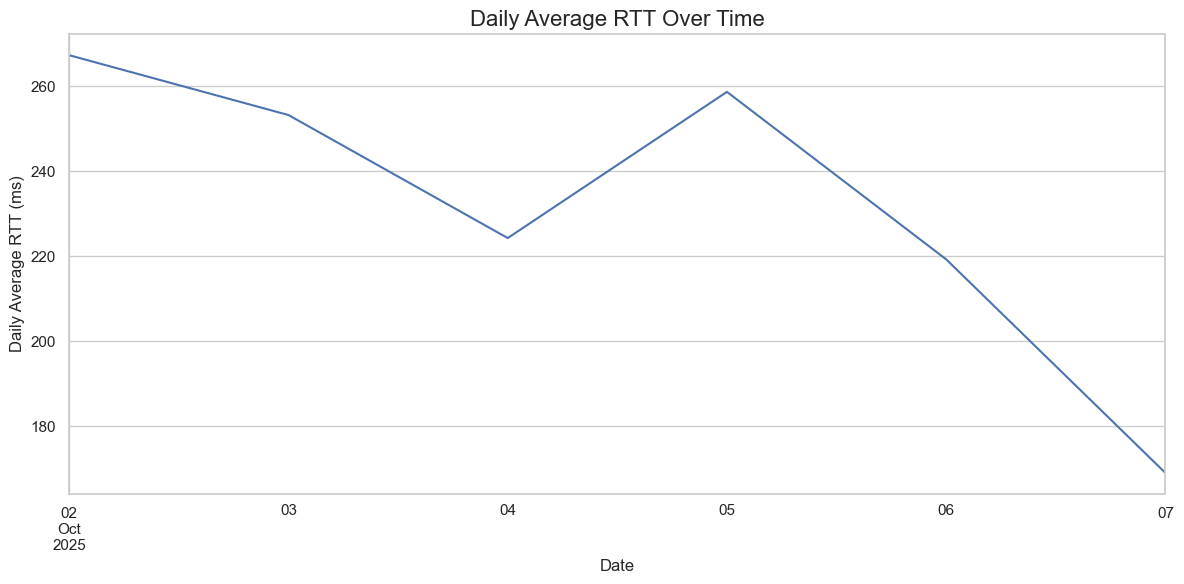

Daily RTT time-series plot saved.

Time-series data from 2025-10-02 00:00:00 to 2025-10-07 00:00:00
created_at_test
2025-10-03    253.176264
2025-10-04    224.266584
2025-10-05    258.624286
2025-10-06    219.260838
2025-10-07    169.065932
Freq: D, Name: avg_rtt, dtype: float64


In [11]:
# 1. Top 10 Worst Performing Pairs (Highest Median RTT)
print("\n--- Top 10 Worst Server-Client Pairs (by Median RTT) ---")
pair_performance_rtt = df_merged.groupby(['s_name', 'c_name'])['avg_rtt'].median().reset_index()
worst_pairs_rtt = pair_performance_rtt.sort_values(by='avg_rtt', ascending=False)
print(worst_pairs_rtt.head(10))

# 2. Top 10 Most Unstable Pairs (Highest Median Jitter)
print("\n--- Top 10 Most Unstable Server-Client Pairs (by Median Jitter) ---")
pair_performance_jitter = df_merged.groupby(['s_name', 'c_name'])['avg_jitter'].median().reset_index()
worst_pairs_jitter = pair_performance_jitter.sort_values(by='avg_jitter', ascending=False)
print(worst_pairs_jitter.head(10))


# 3. Analyze RTT Over Time
print("\n--- Generating RTT over time plot ---")
# Set the 'created_at_test' as the index for time-series resampling
df_ts = df_merged.set_index('created_at_test')

# Resample to get the daily average RTT
df_daily_rtt = df_ts['avg_rtt'].resample('D').mean()

# Drop any days with no data (if any)
df_daily_rtt = df_daily_rtt.dropna()

# Plot the daily average RTT
plt.figure(figsize=(12, 6))
df_daily_rtt.plot()
plt.title('Daily Average RTT Over Time', fontsize=16)
plt.ylabel('Daily Average RTT (ms)')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('daily_avg_rtt_over_time.png')
plt.close()
print("Daily RTT time-series plot saved.")
print(f"\nTime-series data from {df_daily_rtt.index.min()} to {df_daily_rtt.index.max()}")
print(df_daily_rtt.tail()) # Show last few days of data

## Insights from In-Depth Analysis 

### Highest Latency (RTT) Routes

We've identified the **top 10 worst-performing routes** by median RTT.  
This list is dominated by connections between specific **GCP locations**, with the top 3 all exceeding **740 ms**:

1. **GCP_New Delhi-A → GCP_Johannesburg-B:** 746.57 ms  
2. **GCP_New Delhi-B → GCP_Milan-B:** 746.15 ms  
3. **GCP_New Delhi-A → GCP_Lappeenranta-A:** 743.67 ms  

This suggests a **systemic latency issue** for traffic originating from or passing through **GCP_New Delhi**.

---

### Highest Instability (Jitter) Routes

Interestingly, the **most unstable routes** (by median jitter) are completely different.  
The list is led by **Azure locations**, with the top 3 being:

1. **Azure_Milan-A → GCP_Warsaw-C:** 67.23 ms  
2. **Azure_Chennai-A → GCP_Doha-A:** 41.08 ms  
3. **Azure_Gävle-A → GCP_Zürich-B:** 31.48 ms  

**Key Insight:**  
This strongly implies that the root causes for **high latency (RTT)** and **high instability (jitter)** are different.  
- High RTT is often a function of **geographic distance** and **routing**.  
- High jitter can be caused by **network congestion** or **misconfigured hardware** on specific nodes (like *Azure_Milan-A*).

---

### Performance Over Time (`daily_avg_rtt_over_time.png`)

The plot of **daily average RTT** shows the performance trend.  
We have data from **2025-10-02** to **2025-10-07**, with the last few days being:

- **2025-10-05:** 258.62 ms  
- **2025-10-06:** 219.26 ms  
- **2025-10-07:** 169.07 ms  

The plot shows a **significant downward trend** in the last two days, indicating a **recent, broad improvement in network latency**.


## RTT Forecast

C:\Users\ghali\AppData\Local\Temp\ipykernel_9960\4162009658.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly_rtt = df_ts_hourly['avg_rtt'].resample('H').mean().dropna()
c:\dev\slogr\newdata\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\dev\slogr\newdata\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\dev\slogr\newdata\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\de

Resampled to 121 hourly data points.
Training data points: 96
Test data points: 25

--- Model Validation ---
Test Set RMSE: 62.06 ms
Test Set Mean RTT: 160.54 ms

--- Final Forecast ---
Re-fitting model on 100% of hourly data...
24-Hour RTT Forecast:
2025-10-07 18:00:00    230.738919
2025-10-07 19:00:00    230.470392
2025-10-07 20:00:00    230.201865
2025-10-07 21:00:00    229.933338
2025-10-07 22:00:00    229.664811
Freq: h, dtype: float64


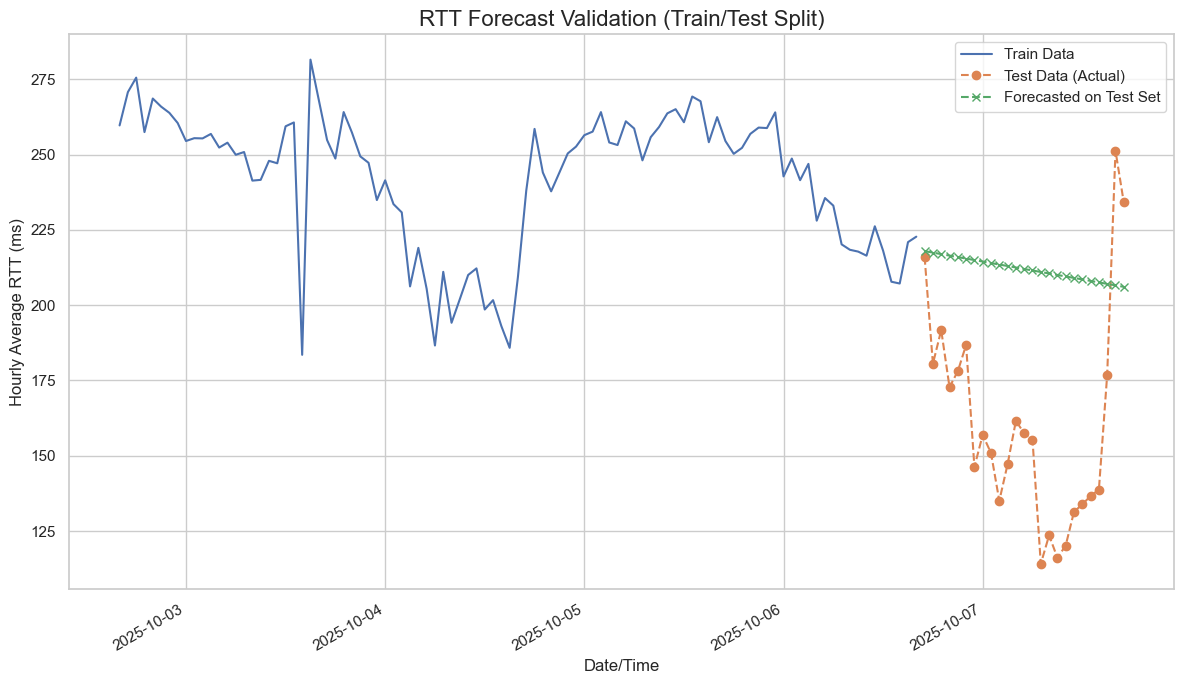

Validation plot saved as 'rtt_forecast_validation.png'


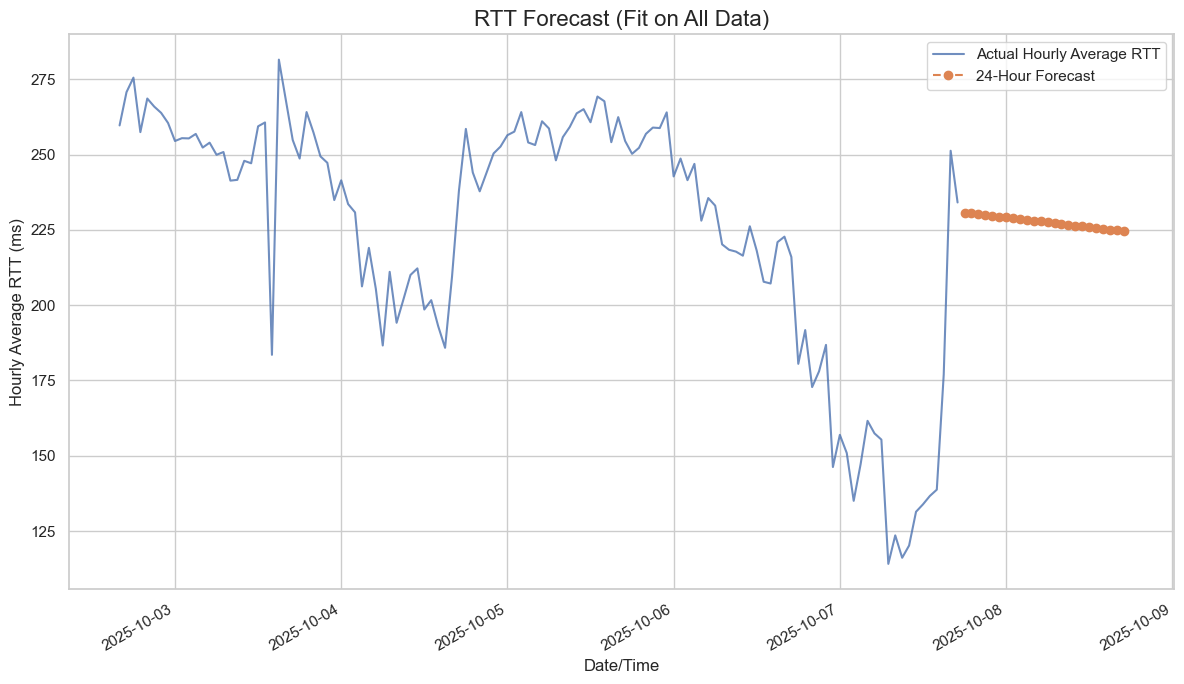

Final 24-hour forecast plot saved as 'rtt_forecast_final_24hr.png'


In [15]:
# We assume df_merged is still in memory from the previous steps.
# If not, the loading and merging steps would need to be re-run.

from statsmodels.tsa.api import Holt
from sklearn.metrics import mean_squared_error
import numpy as np

try:
    # --- 1. Resample Data ---
    # Set index to the test timestamp
    df_ts_hourly = df_merged.set_index('created_at_test')
    
    # Resample to hourly average RTT, dropping any empty hours
    df_hourly_rtt = df_ts_hourly['avg_rtt'].resample('H').mean().dropna()
    
    print(f"Resampled to {len(df_hourly_rtt)} hourly data points.")

    # --- 2. Train/Test Split ---
    # Use 80% for training, 20% for testing
    split_point = int(len(df_hourly_rtt) * 0.8)
    train_data = df_hourly_rtt.iloc[:split_point]
    test_data = df_hourly_rtt.iloc[split_point:]
    
    print(f"Training data points: {len(train_data)}")
    print(f"Test data points: {len(test_data)}")

    # --- 3. Fit Model (on Train data) ---
    # Fit Holt's Linear Trend model to the training data
    model_train = Holt(train_data, initialization_method="estimated")
    fit_train = model_train.fit()

    # --- 4. Validate & Get Accuracy ---
    # Forecast for the length of the test set
    forecast_validation = fit_train.forecast(len(test_data))
    forecast_validation.index = test_data.index # Align index for comparison
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(test_data, forecast_validation))
    print("\n--- Model Validation ---")
    print(f"Test Set RMSE: {rmse:.2f} ms")
    print(f"Test Set Mean RTT: {test_data.mean():.2f} ms")
    
    # --- 5. Create Final Forecast (Fit on All Data) ---
    print("\n--- Final Forecast ---")
    print("Re-fitting model on 100% of hourly data...")
    model_final = Holt(df_hourly_rtt, initialization_method="estimated")
    fit_final = model_final.fit()
    
    # Forecast the next 24 hours
    forecast_final = fit_final.forecast(24)
    forecast_final.index = pd.date_range(start=df_hourly_rtt.index.max() + pd.Timedelta(hours=1), periods=24, freq='H')
    
    print("24-Hour RTT Forecast:")
    print(forecast_final.head())

    # --- 6. Visualize ---
    
    # Plot 1: Validation Plot
    plt.figure(figsize=(12, 7))
    train_data.plot(label='Train Data')
    test_data.plot(label='Test Data (Actual)', marker='o', linestyle='--')
    forecast_validation.plot(label='Forecasted on Test Set', marker='x', linestyle='--')
    plt.title('RTT Forecast Validation (Train/Test Split)', fontsize=16)
    plt.ylabel('Hourly Average RTT (ms)')
    plt.xlabel('Date/Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.savefig('rtt_forecast_validation.png')
    plt.close()
    print("Validation plot saved as 'rtt_forecast_validation.png'")

    # Plot 2: Final Forecast Plot
    plt.figure(figsize=(12, 7))
    df_hourly_rtt.plot(label='Actual Hourly Average RTT', alpha=0.8)
    forecast_final.plot(label='24-Hour Forecast', linestyle='--', marker='o')
    plt.title('RTT Forecast (Fit on All Data)', fontsize=16)
    plt.ylabel('Hourly Average RTT (ms)')
    plt.xlabel('Date/Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.savefig('rtt_forecast_final_24hr.png')
    plt.close()
    print("Final 24-hour forecast plot saved as 'rtt_forecast_final_24hr.png'")

except NameError:
    print("Error: The 'df_merged' DataFrame was not found.")
    print("Please run the initial data loading and merging steps first.")
except Exception as e:
    print(f"An error occurred: {e}")